# 1) Import data and libraries

In [66]:
import sys
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.integrate import cumulative_simpson
sys.path.append('../')
sys.path.append('../modules/')
from Class_sem2dpack import *

# Directory name with output files
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Stage_ISS_v10_Station"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM = sem2dpack(direct1)

Reading grid information...
Reading header file...
0.001 5001 39
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

# 2) Read Fault data

In [67]:
#Definition of a fault data reading function

def read_fault_testing(self, ff=np.float32, LENTAG=1, is_rate_and_state=False, ftag=None):
      
    from distutils import util
    
    ''' Script to read FltXX files.
    Assuming that a single boundary output has been defined for the fault.
    to modify later for multiple fault boundaries...
    , also to modify for files with data > 5.'''

    BC = []; fault = {}
    found = False
    if ftag == None:
        for n, f in enumerate([self.directory+'/Flt'+('%02d' % i)+'_sem2d.hdr' for i in np.arange(1,15)]):
            found = os.path.exists(f)
            print (i, found)
            if found :
                BC.append(n+1)
                print ('Fault boundary: ', BC)
            ##
        ##
    else:
        f = self.directory+'/Flt'+('%02d' % ftag)+'_sem2d.hdr'
        found = os.path.exists(f)
    if found: BC.append(ftag)          
    ##

    if not found : 
        print ('No Flt .hdr file found!')
        return
    ##
    elif not is_rate_and_state:     
        print ('DEBUG :: BC', BC, found)
        # Header file
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_sem2d.hdr'
        data = pd.read_csv(fname, names=('npts','ndat','nsamp','delta'), sep=r'\s+', header=0, nrows=1)
        fault['npts'] = data['npts'].values[0]
        fault['ndat'] = data['ndat'].values[0]
        fault['nsamp'] = data['nsamp'].values[0]
        fault['delta'] = data['delta'].values[0]
        with open(fname, 'r') as f:
            line  = f.readlines()[2:3][0]
            fault['dat_names'] =  [el.replace('\n','').replace(' ','') for el in line.split(':')]
        data = pd.read_csv(fname, names=('x','z'), sep=r'\s+' , header=3)
        fault['x'] = data['x'].values
        fault['z'] = data['z'].values        

        # Init file
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_init_sem2d.tab'
        if os.path.exists(fname):
            data = pd.read_csv(fname, names=('st0','sn0','mu0'), sep=r'\s+', header=None)
            fault['st0'] = data['st0'].values
            fault['sn0'] = data['sn0'].values
            fault['mu0'] = data['mu0'].values

        # Read fault data in a big matrix
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_sem2d.dat'
        if os.path.exists(fname):
            with open(fname, 'rb') as fid:
                whole = np.fromfile(fid, ff) 
                # BUG : nsamp is not correct inside the code !
                try:
                    array = whole.reshape((2*LENTAG+fault['npts'], fault['ndat'], fault['nsamp']), order='F')
                except:
                    fault['nsamp'] -=1
                    array = whole.reshape((2*LENTAG+fault['npts'], fault['ndat'], fault['nsamp']), order='F')

                for j in np.arange(fault['ndat']):
                    print ('Assigning ', fault['dat_names'][j])
                    dat = fault['dat_names'][j]
                    data = array[LENTAG:LENTAG+fault['npts'], j, :]
                    fault [dat] = data
        fault['Time'] = np.linspace(0.0, fault['delta']* (fault['nsamp']), num=fault['nsamp'])

    elif is_rate_and_state:
        
        # Header file
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_sem2d.hdr'
        data = pd.read_csv(fname, names=('npts','ndat'), sep=r'\s+', header=0, nrows=1)
        fault['npts'] = data['npts'].values[0]
        fault['ndat'] = data['ndat'].values[0]    
        with open(fname, 'r') as f:
            line  = f.readlines()[2:3][0]
            fault['dat_names'] =  [el.replace('\n','').replace(' ','') for el in line.split(':')]        
        data = pd.read_csv(fname, names=('x','z'), sep=r'\s+', header=3)
        fault['x'] = data['x'].values
        fault['z'] = data['z'].values         
        
        # Init file
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_init_sem2d.tab'
        if os.path.exists(fname):
            fault['st0'] = np.genfromtxt(fname, usecols=0)
            fault['sn0'] = np.genfromtxt(fname, usecols=1)
            fault['mu0'] = np.genfromtxt(fname, usecols=2)
            fault['theta0'] = np.genfromtxt(fname, usecols=3)
            fault['V0'] = np.genfromtxt(fname, usecols=4)            
            fault['a'] = np.genfromtxt(fname, usecols=5)
            fault['b'] = np.genfromtxt(fname, usecols=6)
        
    
        # Data file I
        # Read fault data in a big matrix
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_sem2d.dat'
        if os.path.exists(fname):
            with open(fname, 'rb') as fid:
                whole = np.fromfile(fid, ff) 
                
                nsamp = len(whole)/(2*LENTAG+fault['npts'])/fault['ndat']
                print ('Guessed array size, nsamp: ', nsamp)
                fault['nsamp'] = int(nsamp)
                
                array = whole.reshape((2*LENTAG+fault['npts'], fault['ndat'], fault['nsamp']), order='F')
                
                for j in np.arange(fault['ndat']):
                    print ('Assigning ', fault['dat_names'][j])
                    dat = fault['dat_names'][j]
                    data = array[LENTAG:LENTAG+fault['npts'], j, :]
                    fault[dat] = data                    
                
                
        # Data file II 
        # Read fault data in a big matrix
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_time_sem2d.tab'        
        if os.path.exists(fname):
            print(fname)
            fault['it'] = np.genfromtxt(fname, usecols=0)
            fault['dt'] = np.genfromtxt(fname, usecols=1)
            fault['t'] = np.genfromtxt(fname, usecols=2)
            fault['#EQ'] = np.genfromtxt(fname, usecols=3)
            dum = np.genfromtxt(fname, usecols=4, dtype=str)
            fault['isDyn'] = np.array( [bool(util.strtobool(d)) for d in dum] )             
            dum = np.genfromtxt(fname, usecols=5, dtype=str)
            fault['isSwitch'] = np.array( [bool(util.strtobool(d)) for d in dum] )
            dum = np.genfromtxt(fname, usecols=6, dtype=str)
            fault['isEq'] = np.array( [bool(util.strtobool(d)) for d in dum] )      

        # Data file III
        # Read potency and potency rate, currently only for out-of-plane (ndof=1)
        # for in-plane models change usecols and potency* arrays' size
        fname = self.directory+'/Flt'+str('%02d' % BC[0])+'_potency_sem2d.tab'        
        if os.path.exists(fname):
            print(fname)
            # POTENCY
            # out-of plane model -- compo 13
            # replace D by e for python 
            array = np.genfromtxt(fname,usecols=0, dtype=None,  encoding=None)
            array_fixed  = np.array( [float(dum.replace('D','e')) for dum in array])
            fault['potency'] = np.zeros((array_fixed.shape[0], 2))
            fault['potency_rate'] = np.zeros((array_fixed.shape[0], 2))    
            fault['potency'][:,0] = array_fixed
            
            # out-of plane model -- compo 23
            array = np.genfromtxt(fname,usecols=1, dtype=None,  encoding=None)
            array_fixed  = np.array( [float(dum.replace('D','e')) for dum in array])    
            fault['potency'][:,1] = array_fixed
            
            # POTENCY RATE
            # out-of plane model -- compo 13
            array = np.genfromtxt(fname,usecols=2, dtype=None,  encoding=None)
            array_fixed  = np.array( [float(dum.replace('D','e')) for dum in array])    
            fault['potency_rate'][:,0] = array_fixed
                
            # out-of plane model -- compo 23
            array = np.genfromtxt(fname,usecols=3, dtype=None,  encoding=None)
            array_fixed  = np.array( [float(dum.replace('D','e')) for dum in array])    
            fault['potency_rate'][:,1] = array_fixed    

    self.fault = fault        

    # Find the earthquake
    if is_rate_and_state:
        cdt_beg = (self.fault['isDyn']==True) & (np.roll(self.fault['isDyn'], 1)==False)
        cdt_end = (self.fault['isDyn']==True) & (np.roll(self.fault['isDyn'], -1)==False)
        index = np.arange(0, len(self.fault['isDyn']))
        print ('Number of dynamic beginning and ending points:', len(index[cdt_beg]), len(index[cdt_end]))   
    ##
    return 
###

In [136]:
#Read data

read_fault_testing(SEM, ftag=5)
BC_bottom = SEM.fault
##

read_fault_testing(SEM, ftag=7)
BC_right = SEM.fault
##

read_fault_testing(SEM, ftag=9)
BC_left = SEM.fault
##

DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction


# 3) Plot Input Signal

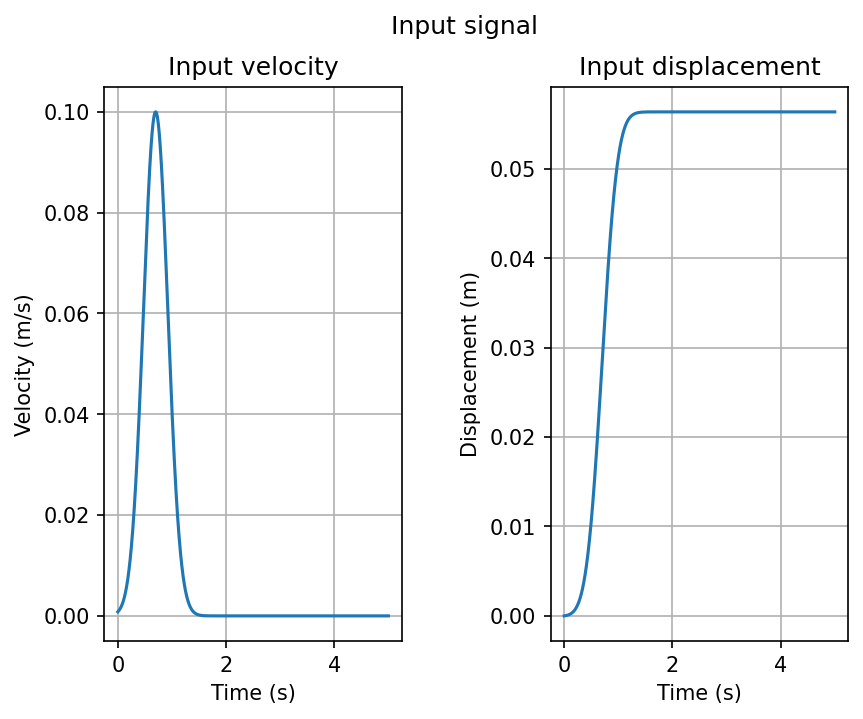

In [69]:
#Load input signal
input_signal_path = SEM.directory + '/' + 'SourcesTime_sem2d.tab'
input_signal = np.genfromtxt(open(input_signal_path,'r'))
time = input_signal[:,0]
input_velocity = input_signal[:,1]

#Create figure
fig = plt.figure()
fig.subplots_adjust(wspace=0.5)
fig.suptitle("Input signal")

#Create velocity plot
ax_V = fig.add_subplot(1,2,1)
ax_V.set_xlabel("Time (s)")
ax_V.set_ylabel("Velocity (m/s)")
ax_V.set_title("Input velocity")
ax_V.grid(True)
ax_V.plot(time, input_velocity)

#Create displacement plot
input_displacement = cumulative_simpson(input_velocity,x=time)

ax_D = fig.add_subplot(1,2,2)
ax_D.set_xlabel("Time (s)")
ax_D.set_ylabel("Displacement (m)")
ax_D.set_title("Input displacement")
ax_D.grid(True)
ax_D.plot(time[1:], input_displacement)




# 4) Extra stations

## Drawing of the stations

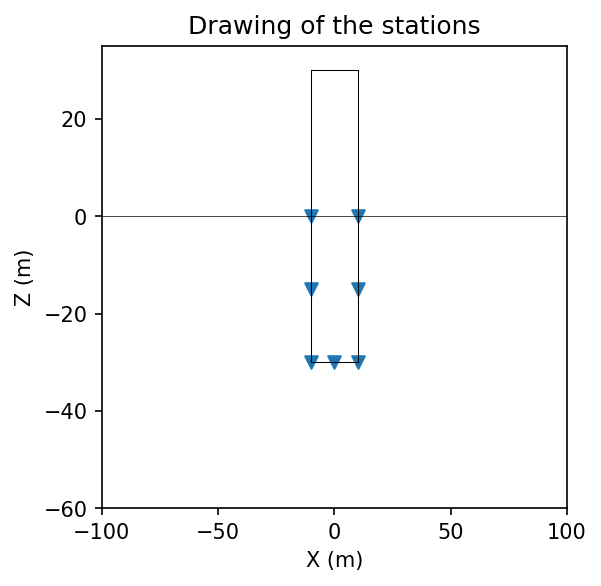

In [70]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))

#Desired stations
stations_0 = [19,32]
stations_m15 = [22,35]
stations_m30 = [12,25,38]
stations = np.concatenate([stations_0, stations_m15, stations_m30])

#Draw the plot
XSTA, ZSTA = SEM.rcoord[:,0][stations], SEM.rcoord[:,1][stations]
ax.scatter(XSTA, ZSTA, marker='v')
ax.set_title("Drawing of the stations")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_xlim(-100, 100)
ax.set_ylim(-60, 35)

lw = 0.5
ax.plot([-10, -10], [-30, 30], 'k', lw=lw)
ax.plot([10, 10], [-30, 30], 'k', lw=lw)
ax.plot([-10, 10], [-30, -30], 'k', lw=lw)
ax.plot([-10, 10], [30, 30], 'k', lw=lw)
ax.plot([-100, 100], [0, 0], 'k', lw=lw/1.5)

## Seismograms of the stations

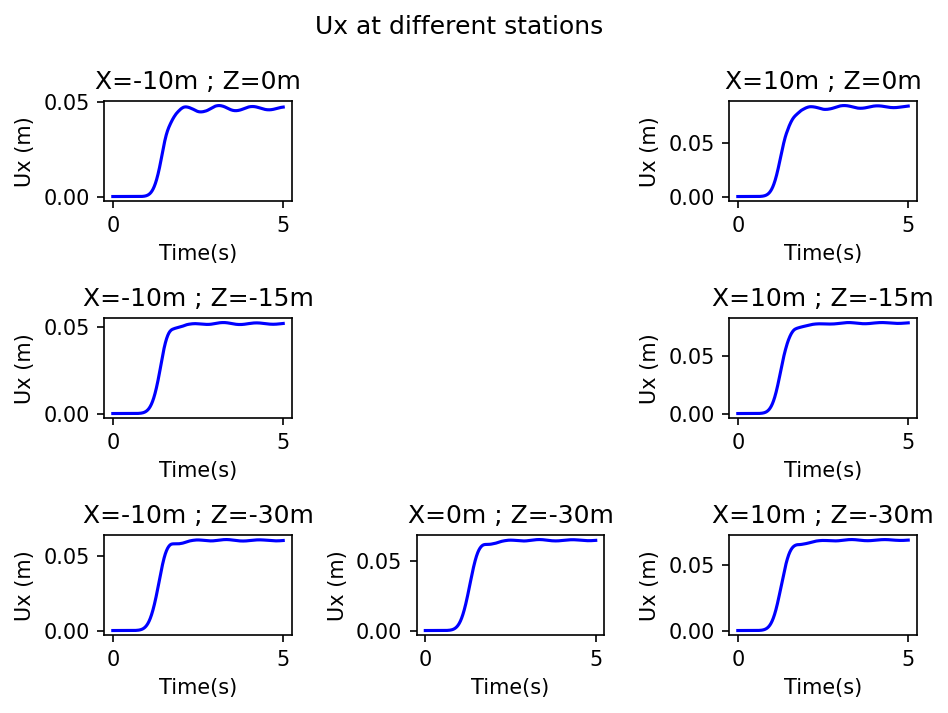

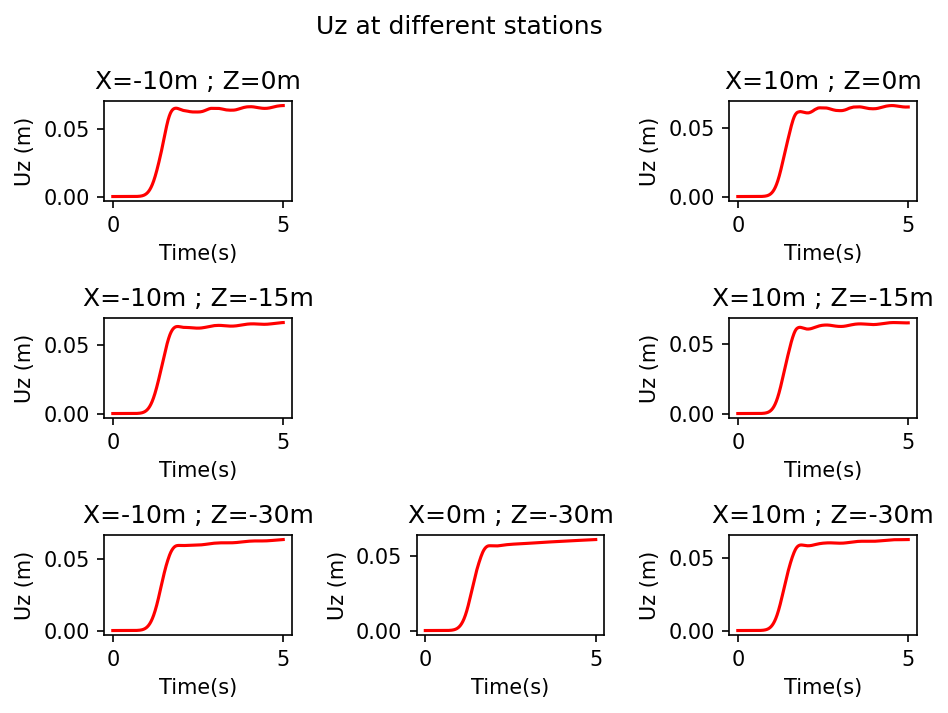

In [71]:
#Desired stations
stations = [12, 19, 22, 25, 32, 35, 38]
stations_index = [8, 1, 4, 7, 3, 6, 9]
XSTA, ZSTA = SEM.rcoord[:,0][stations], SEM.rcoord[:,1][stations]

#Get seismograms
SEM.read_seismo('x')
time = SEM.time
Vx = SEM.velocity[:,stations]
SEM.read_seismo('z')
Vz = SEM.velocity[:,stations]

#Plot
plt.rcParams['figure.dpi'] = 150

def plot_seismo_shape(component):
    fig = plt.figure()
    fig.suptitle(f"U{component} at different stations")
    n_stations = len(stations)
    for i,s in enumerate(stations):
        ax = fig.add_subplot(3,3,stations_index[i])
        ax.set_title("X={:.0f}m ; Z={:.0f}m".format(XSTA[i],ZSTA[i]))
        ax.set_xlabel("Time(s)")
        ax.set_ylabel(f"U{component} (m)")
        if component == 'x':
            V = Vx
            c = 'blue'
        elif component == 'z':
            V = Vz
            c = 'red'
        U = cumulative_simpson(V[:,i],x=time)
        ax.plot(time[1:], U, color=c)
    fig.tight_layout()
    plt.show()

plot_seismo_shape('x')
plot_seismo_shape('z')

## Comparison with fault data

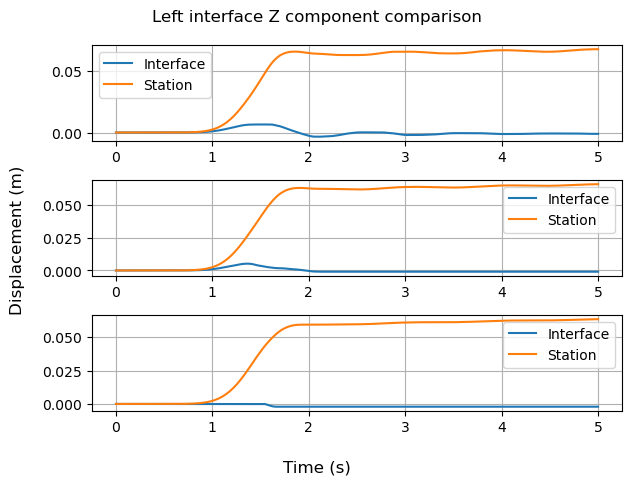

In [121]:
stations_left_rec = [19, 22, 25]
stations_bottom_rec = [25, 12, 38]
stations_right_rec = [32, 35, 38]

stations_left = [12, 7, 0]
stations_bottom = [0, 4, 8]
stations_right = [12, 7, 0]


Slip_1_L = BC_left['Slip_1']
Slip_1_B = BC_bottom['Slip_1']
Slip_1_R = BC_right['Slip_1']

Slip_2_L = BC_left['Slip_2']
Slip_2_B = BC_bottom['Slip_2']
Slip_2_R = BC_right['Slip_2']

time = BC_left['Time']

dic = {}
dic["Left"] = stations_left_rec, stations_left, Slip_1_L, Slip_2_L, 'z'
dic["Bottom"] = stations_bottom_rec, stations_bottom, Slip_1_B, Slip_2_B, 'x'
dic["Right"] = stations_right_rec, stations_right, Slip_1_R, Slip_2_R, 'z'

def read_data(comp, station):
    SEM.read_seismo(comp)
    time_rec = SEM.time
    V = SEM.velocity[:,station]
    return time_rec, V

def plot_component(interf, comp):
    fig = plt.figure()
    fig.suptitle(f"{interf} interface {comp.upper()} component comparison")
    fig.supxlabel("Time (s)")
    fig.supylabel("Displacement (m)")
    s_rec, s, Slip_1, Slip_2, S1_dir = dic[interf]
    time_rec, V = read_data('z',s_rec)
    for i in range(3):
        ax = fig.add_subplot(3,1,i+1)
        U = cumulative_simpson(V[:,i],x=time_rec)
        if S1_dir==comp:
            ax.plot(time, Slip_1[s[i],:], label="Interface")
        else:
            ax.plot(time, Slip_2[s[i],:], label="Interface")
        ax.plot(time_rec[1:],U, label="Station")
        ax.legend()
        ax.grid(True)
    fig.tight_layout()
        
plot_component('Left','z')



## Deformed structure

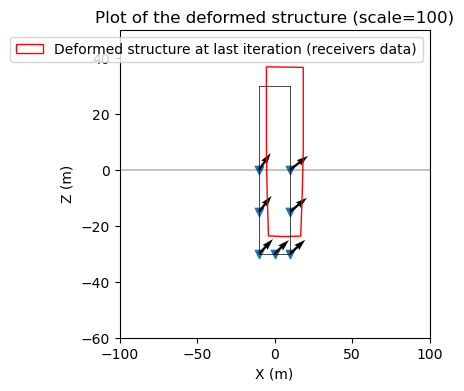

In [118]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))

#Desired stations
stations_0 = [19,32]
stations_m15 = [22,35]
stations_m30 = [12,25,38]
stations = np.array([19, 22, 25, 12, 38, 35, 32])

#Get seismograms
SEM.read_seismo('x')
time = SEM.time
Vx = SEM.velocity[:,stations]
SEM.read_seismo('z')
Vz = SEM.velocity[:,stations]

#Draw the plot
XSTA, ZSTA = SEM.rcoord[:,0][stations], SEM.rcoord[:,1][stations]
ax.scatter(XSTA, ZSTA, marker='v')

ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_xlim(-100, 100)
ax.set_ylim(-60, 50)

lw = 0.5
ax.plot([-10, -10], [-30, 30], 'k', lw=lw)
ax.plot([10, 10], [-30, 30], 'k', lw=lw)
ax.plot([-10, 10], [-30, -30], 'k', lw=lw)
ax.plot([-10, 10], [30, 30], 'k', lw=lw)
ax.plot([-100, 100], [0, 0], 'k', lw=lw/1.5)

scale = 100
x_disp = []
z_disp = []
ax.set_title(f"Plot of the deformed structure (scale={scale})")
for i,s in enumerate(stations):
    Ux = cumulative_simpson(Vx[:,i],x=time)
    Uz = cumulative_simpson(Vz[:,i],x=time)
    x_disp.append(XSTA[i]+scale*Ux[-1])
    z_disp.append(ZSTA[i]+scale*Uz[-1])
    #ax.scatter(XSTA[i]+scale*Ux[-1], ZSTA[i]+scale*Uz[-1], marker='v')
    ax.quiver(XSTA[i], ZSTA[i], Ux[-1], Uz[-1], scale=1/scale, scale_units='xy')
ax.fill([x_disp[0]]+x_disp+[x_disp[-1]],[z_disp[0]+30]+z_disp+[z_disp[-1]+30], facecolor='none', edgecolor='red', label="Deformed structure at last iteration (receivers data)")
ax.legend()

# 3) Post Processing

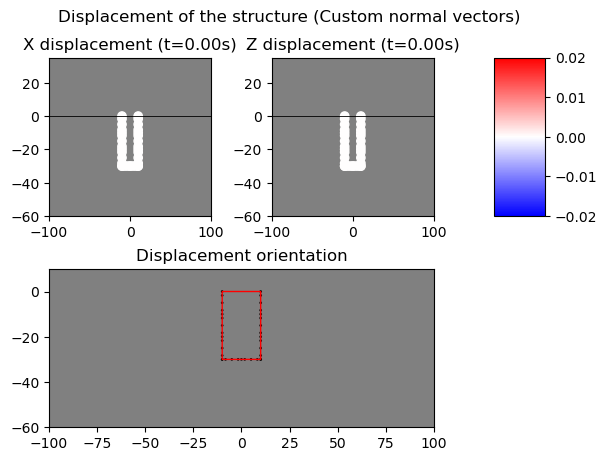

In [134]:
fig = plt.figure()
fig.subplots_adjust(wspace=1.2, hspace=1)
ax_X = fig.add_subplot(4,5,(1,7))
ax_Z = fig.add_subplot(4,5,(3,9))
cax = fig.add_subplot(4,5,(5,10))
ax_quiver = fig.add_subplot(4,5,(11,19))

plt.rcParams['figure.dpi'] = 100
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

X_sum = np.concatenate([ np.flip(BC_left['x']), BC_bottom['x'], BC_right['x'] ])
Z_sum = np.concatenate([ np.flip(BC_left['z']), BC_bottom['z'], BC_right['z'] ])

cmap = 'bwr'
bounds = [-0.02,0.02]
scalar_mappable = ScalarMappable(norm=Normalize(bounds[0],bounds[1]), cmap=cmap)
cb = plt.colorbar(scalar_mappable,cax=cax)

fig.suptitle("Displacement of the structure (Custom normal vectors)")

def animate(t):
    ax_X.cla()
    ax_Z.cla()
    ax_quiver.cla()
    #X_comp = np.concatenate([-BC_left['Slip_2'][:,t], BC_bottom['Slip_1'][:,t], BC_right['Slip_2'][:,t]])
    #Z_comp = np.concatenate([-BC_left['Slip_1'][:,t], -BC_bottom['Slip_2'][:,t], BC_right['Slip_1'][:,t]])
    X_comp = np.concatenate([np.flip(BC_left['Slip_2'][:,t]), -BC_bottom['Slip_1'][:,t], BC_right['Slip_2'][:,t]])
    Z_comp = np.concatenate([np.flip(-BC_left['Slip_1'][:,t]), BC_bottom['Slip_2'][:,t], BC_right['Slip_1'][:,t]])
    scalar_mappable = ScalarMappable(norm=Normalize(bounds[0],bounds[1]), cmap=cmap)
    cb.update_normal(scalar_mappable)

    ax_X.scatter(X_sum, Z_sum, c=X_comp, cmap=scalar_mappable.cmap, norm=scalar_mappable.norm)
    ax_X.plot([-100,100],[0,0],c='black',lw=0.6)
    ax_X.set_facecolor('grey')       
    ax_X.set_xlim(-100, 100)
    ax_X.set_ylim(-60, 35)
    ax_X.set_title("X displacement (t={:.2f}s)".format(t*1e-5))

    ax_Z.scatter(X_sum, Z_sum, c=Z_comp, cmap=scalar_mappable.cmap, norm=scalar_mappable.norm)
    ax_Z.plot([-100,100],[0,0],c='black',lw=0.6)
    ax_Z.set_facecolor('grey')            
    ax_Z.set_xlim(-100, 100)
    ax_Z.set_ylim(-60, 35)
    ax_Z.set_title("Z displacement (t={:.2f}s)".format(t*1e-5))

    
    scale = 150
    ax_quiver.quiver(X_sum, Z_sum, X_comp, Z_comp, scale=1/scale, scale_units='xy', angles='xy')
    ax_quiver.fill(X_sum + scale*X_comp, Z_sum + scale*Z_comp, facecolor='none', edgecolor='red')
    ax_quiver.set_facecolor('grey')
    ax_quiver.set_xlim(-100, 100)
    ax_quiver.set_ylim(-60, 10)
    ax_quiver.set_title("Displacement orientation")


anim.FuncAnimation(fig, animate, np.arange(0,500000,5000))

#writervideo = anim.PillowWriter(fps=10)
#animation = anim.FuncAnimation(fig, animate, np.arange(0,500000,5000))
#animation.save('./Custom_Normal.gif', writer=writervideo) 

